# Dimension reduction: t-SNE

Peter Ralph  
2026-02-04

# t-SNE

## t-SNE

<figure>
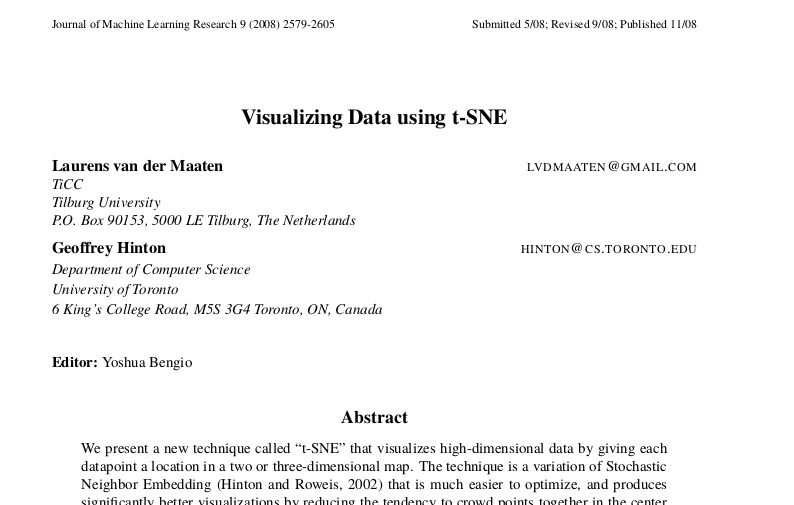
<figcaption
aria-hidden="true">http://www.jmlr.org/papers/volume9/vandermaaten08a/vandermaaten08a.pdf</figcaption>
</figure>

------------------------------------------------------------------------

[t-SNE](https://en.wikipedia.org/wiki/T-distributed_stochastic_neighbor_embedding)
is a new-er-than-PCA method for dimension reduction (visualization of
struture in high-dimensional data).

You can think about this as a lengthy exercise in “let’s dissect a
sophisticated loss function for dimension reduction”.

------------------------------------------------------------------------

It [makes very nice
visualizations](https://distill.pub/2016/misread-tsne/).

------------------------------------------------------------------------

The *generic idea* is to find a low dimensional representation (i.e., a
*picture*) in which *proximity* of points reflects *similarity* of the
corresponding (high dimensional) observations.

------------------------------------------------------------------------

Suppose we have $n$ data points, $x_1, \ldots, x_n$ and each one has $p$
variables: $x_1 = (x_{11}, \ldots, x_{1p})$.

For each, we want to find a low-dimensional point $y$: $$\begin{aligned}
    x_i \mapsto y_i
\end{aligned}$$ similarity of $x_i$ and $x_j$ is (somehow) reflected by
proximity of $y_i$ and $y_j$

We need to define:

1.  “low dimension” (usually, $k=2$ or $3$)
2.  “similarity” of $x_i$ and $x_j$
3.  “reflected by proximity” of $y_i$ and $y_j$

## Similarity

To measure similarity, we just use (Euclidean) distance:
$$\begin{aligned}
    d(x_i, x_j) = \sqrt{\sum_{\ell=1}^n (x_{i\ell} - x_{j\ell})^2} ,
\end{aligned}$$ after first normalizing variables to vary on comparable
scales.

## Proximity

A natural choice is to require distances in the new space
($d(y_i, y_j)$) to be as close as possible to distances in the original
space ($d(x_i, x_j)$).

That’s a *pairwise* condition. t-SNE instead tries to measure how
faithfully *relative distances* are represented in each point’s
*neighborhood*.

## Neighborhoods

For each data point $x_i$, define $$\begin{aligned}
    p_{ij} = \frac{ e^{-d(x_i, x_j)^2 / (2\sigma^2)} 
                  }{ \sum_{\ell \neq i} e^{-d(x_i, x_\ell)^2 / (2 \sigma^2)} } ,
\end{aligned}$$ and $p_{ii} =  0$.

This is the probability that point $i$ would pick point $j$ as a
neighbor if these are chosen according to the Gaussian density centered
at $x_i$.

------------------------------------------------------------------------

*Exercise:*

1.  Draw 9 points in a 10m x 10m square. Label the points 1 to 9.
2.  Draw another square, and try to draw the points 1 to 9 in *that* one
    so that the neighborhood of point `1` is similar to the first
    picture, but the neighborhood of point `9` is not.

*Reminder:* the “neighborhood” is defined by relative distances: for
point $i$ it is $$\begin{aligned}
    p_{ij} = \frac{ e^{-d(x_i, x_j)^2 / (2\sigma^2)} 
                  }{ \sum_{\ell \neq i} e^{-d(x_i, x_\ell)^2 / (2 \sigma^2)} } ,
\end{aligned}$$ and $p_{ii} =  0$.

------------------------------------------------------------------------

Similarly, in the output space, define $$\begin{aligned}
    q_{ij} = \frac{ (1 + d(y_i, y_j)^2)^{-1} 
                  }{ \sum_{\ell \neq i} (1 + d(y_i, y_\ell)^2)^{-1} }
\end{aligned}$$ and $q_{ii} =  0$.

This is the probability that point $i$ would pick point $j$ as a
neighbor if these are chosen according to the Cauchy centered at $x_i$.

## Similiarity of neighborhoods

We want neighborhoods to look similar, i.e., choose $y$ so that $q$
looks like $p$.

To do this, we minimize $$\begin{aligned}
    \text{KL}(p \;|\; q)
    &=
    \sum_{i} \sum_{j} p_{ij} \log\left(\frac{p_{ij}}{q_{ij}}\right) .
\end{aligned}$$

*What’s KL()?*

## Kullback-Leibler divergence

$$\begin{aligned}
    \text{KL}(p \;|\; q)
    &=
    \sum_{i} \sum_{j} p_{ij} \log\left(\frac{p_{ij}}{q_{ij}}\right) .
\end{aligned}$$

This is the average log-likelihood ratio between $p$ and $q$ for a
single observation drawn from $p$.

It is a measure of how “surprised” you would be by a sequence of samples
from $p$ that you think should be coming from $q$.

**Facts:**

1.  $\text{KL}(p \;|\; q) \ge 0$

2.  $\text{KL}(p \;|\; q) = 0$ only if $p_i = q_i$ for all $i$.

## Summary ($t$-SNE):

Given data $\{ x_i \in \mathbb{R}^n \}$, find locations
$\{ y_i \in \mathbb{R}^k \}$ to minimize $$\begin{aligned}
    \sum_{ij} p_{ij} \log(p_{ij} / q_{ij}) ,
\end{aligned}$$ where $p_{ij} \propto e^{-d_{ij}^2/\sigma^2}$ and
$q_{ij} \propto 1/(1 + d_{ij}^2)$, and rows in $p$ and $q$ are
normalized to sum to 1.

# Simulate data

## set-up

In [ ]:
import numpy as np
import pandas as pd
import plotnine as p9
import seaborn as sns
import scipy
import scipy.optimize
rng = np.random.default_rng(seed=123)

## A high-dimensional donut

Let’s first make some data. This will be some points distributed around
a ellipse in $n$ dimensions.

In [ ]:
n = 20
npts = 1000
xy = rng.normal(size=n*npts).reshape((npts, n))
theta = rng.uniform(size=npts) * 2 * np.pi
theta.sort()
ab = rng.normal(size=2*n).reshape((2, n))
ab[:,1] = ab[:,1] - ab[:,0] * np.sum(ab[:,0] * ab[:,1]) / np.sqrt(np.sum(ab[:,1]**2))
ab /= np.sqrt(np.sum(ab**2, axis=1))[:,np.newaxis]
for k in range(npts):
    dxy = 4 * np.array([np.cos(theta[k]), np.sin(theta[k])]).dot(ab)
    xy[k,:] += dxy

------------------------------------------------------------------------

Here’s what the data look like:

In [ ]:
sns.pairplot(pd.DataFrame(xy))

------------------------------------------------------------------------

But there is hidden, two-dimensional structure:

In [ ]:
(
    pd.DataFrame(xy.dot(ab.T), columns=('a', 'b')).reset_index()
    >>
    p9.ggplot(p9.aes(x='a', y='b', color='index')) + p9.geom_point()
)

## Okay, so again:

Given data $\{ x_i \in \mathbb{R}^n \}$, find locations
$\{ y_i \in \mathbb{R}^k \}$ to minimize $$\begin{aligned}
    \sum_{ij} p_{ij} \log(p_{ij} / q_{ij}) ,
\end{aligned}$$ where $p_{ij} \propto e^{-d_{ij}^2/\sigma^2}$ and
$q_{ij} \propto 1/(1 + d_{ij}^2)$, and rows in $p$ and $q$ are
normalized to sum to 1.

*You* could implement $t$-SNE, with that description.

## But, let’s lean on `skelearn` instead:

In [ ]:
import sklearn.manifold
tsne = sklearn.manifold.TSNE(n_components=2).fit_transform(xy)
tsne

## It works!

In [ ]:
(
    pd.DataFrame(tsne, columns=["coord1", "coord2"]).reset_index()
    >>
    p9.ggplot(p9.aes(x="coord1", y="coord2", color='index'))
    + p9.geom_point()
)

# Another case

## High-dimensional random walk

In [ ]:
n = 40
npts = 100
rw = rng.normal(size=n*npts).reshape((npts, n))
for i in range(1, npts):
    rw[i,:] = np.sqrt(.9) * rw[i-1,:] + np.sqrt(.1) * rw[i,:]

------------------------------------------------------------------------

In [ ]:
sns.pairplot(pd.DataFrame(rw[:,:10]))

## Run again

In [ ]:
rw_tsne = sklearn.manifold.TSNE(n_components=2).fit_transform(rw)
rw_tsne

## It works!

In [ ]:
(
    pd.DataFrame(rw_tsne, columns=["coord1", "coord2"]).reset_index()
    >>
    p9.ggplot(p9.aes(x="coord1", y="coord2", color='index'))
    + p9.geom_point()
)